In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q
!pip install shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.2 MB/s eta 0:00:00


# 20 — Subgroup Analysis
### Early Sepsis Detection — Phase 22

Evaluates **LightGBM (tuned) + isotonic calibration + threshold=0.1**
(our locked final model) separately by age group, gender, ICU unit
(Unit1), and source_set — using the validation set.

**Fairness caveat (stated once, applies throughout):** similar subgroup
performance does NOT by itself establish fairness — it only means these
particular metrics did not detect a disparity on this particular dataset.
Differences ARE flagged and discussed honestly where found, without
overclaiming their cause.


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src import config
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]

patient_df = pd.read_parquet(config.PROCESSED_PATIENT_LEVEL_PARQUET)

# CRITICAL (per Phase 21's bug fix): replicate the EXACT SAME filter used
# by src/preprocessing.py's transform_split() — a boolean mask, NOT a
# reorder — so X_val's row order matches patient_df_val's row order
# position-for-position. Re-indexing to a differently-ordered id array
# here would silently scramble every prediction (as happened before the
# Phase 21 fix).
split_lookup = pd.read_parquet(config.PROCESSED_DIR / "patient_split_assignment.parquet")
val_ids = split_lookup.loc[split_lookup["split"] == "val", config.PATIENT_ID_COL].to_numpy()
patient_df_val = patient_df[patient_df[config.PATIENT_ID_COL].isin(val_ids)].reset_index(drop=True)

assert len(patient_df_val) == X_val.shape[0], "Row count mismatch — alignment assumption violated!"

calibrator = joblib.load(config.MODELS_DIR / "lightgbm_tuned_calibrated.pkl")
val_prob = calibrator.predict_proba(X_val)[:, 1]
patient_df_val["pred_prob"] = val_prob

labels_match = (patient_df_val["label"].to_numpy() == y_val).all()
print(f"Alignment check passed: {labels_match}")
assert labels_match, "ALIGNMENT BUG detected!"

FINAL_THRESHOLD = 0.1


Alignment check passed: True


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 1. Define subgroups

Age is binned into clinically-conventional ranges. Unit1 uses the Phase 3
encoding (0/1/-1=unknown).


In [4]:
patient_df_val["age_group"] = pd.cut(
    patient_df_val["Age"],
    bins=[0, 40, 65, 80, 120],
    labels=["<40", "40-65", "65-80", "80+"],
)

subgroup_cols = {
    "age_group": "age_group",
    "Gender": "Gender",
    "Unit1": "Unit1",
    config.SOURCE_SET_COL: config.SOURCE_SET_COL,
}
for name, col in subgroup_cols.items():
    print(f"\n{col} value counts:")
    print(patient_df_val[col].value_counts(dropna=False))



age_group value counts:
age_group
40-65    2501
65-80    1922
80+       820
<40       662
Name: count, dtype: int64

Gender value counts:
Gender
1.0    3285
0.0    2620
Name: count, dtype: int64

Unit1 value counts:
Unit1
NaN    2311
1.0    1802
0.0    1792
Name: count, dtype: int64

source_set value counts:
source_set
A    2977
B    2928
Name: count, dtype: int64


## 2. Compute full metrics per subgroup

Uses the SAME `evaluate.py` metric suite as every other model comparison
in this project, at the locked threshold=0.1.


In [5]:
def subgroup_metrics(df, group_col):
    rows = []
    for group_val, sub in df.groupby(group_col, observed=True):
        if sub["label"].sum() == 0 or len(sub) < 20:
            # Skip groups with no positive cases or too few patients —
            # ROC-AUC/PR-AUC are undefined or unreliable at tiny sample sizes.
            continue
        m = ev.compute_metrics(sub["label"].to_numpy(), sub["pred_prob"].to_numpy(), threshold=FINAL_THRESHOLD)
        m[group_col] = group_val
        m["n_patients"] = len(sub)
        m["n_positive"] = int(sub["label"].sum())
        rows.append(m)
    return pd.DataFrame(rows)

age_results = subgroup_metrics(patient_df_val, "age_group")
gender_results = subgroup_metrics(patient_df_val, "Gender")
unit_results = subgroup_metrics(patient_df_val, "Unit1")
source_results = subgroup_metrics(patient_df_val, config.SOURCE_SET_COL)

display_cols = ["n_patients", "n_positive", "roc_auc", "pr_auc", "precision", "recall_sensitivity", "specificity", "f1"]

print("--- By Age Group ---")
display(age_results[["age_group"] + display_cols])

print("--- By Gender ---")
display(gender_results[["Gender"] + display_cols])

print("--- By ICU Unit (Unit1) ---")
display(unit_results[["Unit1"] + display_cols])

print("--- By Source Set ---")
display(source_results[[config.SOURCE_SET_COL] + display_cols])


--- By Age Group ---


,age_group,n_patients,n_positive,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1
0,<40,662,40,0.752371,0.241645,0.160305,0.525000,0.823151,0.245614
1,40-65,2501,134,0.800461,0.254446,0.159046,0.597015,0.821293,0.251177
2,65-80,1922,145,0.753017,0.253777,0.189310,0.586207,0.795160,0.286195
3,80+,820,50,0.713299,0.132767,0.138122,0.500000,0.797403,0.216450


--- By Gender ---


,Gender,n_patients,n_positive,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1
0,0.0,2620,155,0.740728,0.183799,0.145594,0.490323,0.819067,0.224520
1,1.0,3285,214,0.785626,0.268786,0.181941,0.630841,0.802345,0.282427


--- By ICU Unit (Unit1) ---


,Unit1,n_patients,n_positive,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1
0,0.0,1792,89,0.755742,0.217289,0.177033,0.415730,0.899002,0.248322
1,1.0,1802,111,0.788683,0.263508,0.164286,0.621622,0.792431,0.259887


--- By Source Set ---


,source_set,n_patients,n_positive,roc_auc,pr_auc,precision,recall_sensitivity,specificity,f1
0,A,2977,230,0.765600,0.254563,0.167756,0.669565,0.721878,0.268293
1,B,2928,139,0.742365,0.199115,0.164740,0.410072,0.896379,0.235052


## 3. Visualize subgroup ROC-AUC and recall side by side

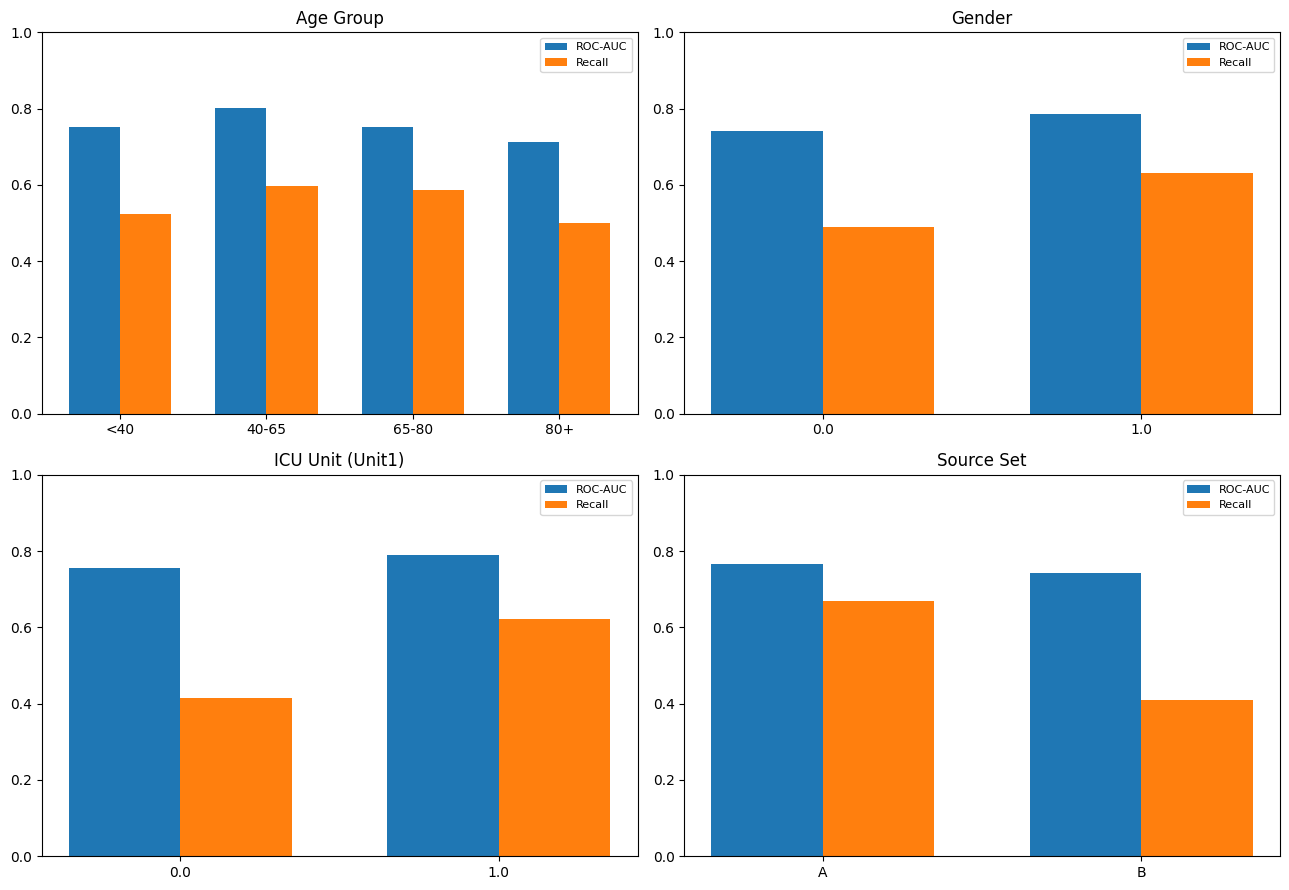

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (df, col, title) in zip(axes.flat, [
    (age_results, "age_group", "Age Group"),
    (gender_results, "Gender", "Gender"),
    (unit_results, "Unit1", "ICU Unit (Unit1)"),
    (source_results, config.SOURCE_SET_COL, "Source Set"),
]):
    x = np.arange(len(df))
    width = 0.35
    ax.bar(x - width/2, df["roc_auc"], width, label="ROC-AUC")
    ax.bar(x + width/2, df["recall_sensitivity"], width, label="Recall")
    ax.set_xticks(x)
    ax.set_xticklabels(df[col].astype(str))
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "20_subgroup_performance.png", dpi=150)
plt.show()


## 4. Discussion of findings

**What to look for:** any subgroup with a MUCH lower recall or ROC-AUC
than the overall model (Phase 19: ROC-AUC~0.75, recall~0.52-0.61) would
mean that group is systematically underserved by this model — this
should be reported honestly regardless of the cause, and NOT interpreted
as "the model is fair" simply because most groups look similar.

**Known relevant context from Phase 21:** source_set A had a notably
higher false-positive rate than source_set B — if that pattern also shows
up here as a source_set difference in precision/specificity, it corroborates
Phase 21's finding rather than being a new coincidence.


---
### What to send back to Claude after running this notebook

- Section 2's four subgroup tables (age, gender, unit, source_set)
- Any subgroup that stands out as notably weaker (lower ROC-AUC or recall)
  than the overall model's validation performance

With that, **Phase 22 is complete**, and we move to **Phase 23 (Final
Model Selection)** — formally justifying LightGBM (tuned) + isotonic
calibration + threshold=0.1 as the final model, and creating
`model_metadata.json`.
